# Building Your First Neural Network - Your PyTorch Launchpad

Welcome to your comprehensive introduction to PyTorch! This notebook covers everything you need to get started with deep learning.

## 📚 What you'll learn:
- ⚙️ Setting up PyTorch and checking your environment
- 🧮 Working with tensors (PyTorch's fundamental data structure)
- 🚀 Using GPUs for faster computation
- 🧠 Building neural networks from scratch
- 📊 Creating and handling datasets
- 🎯 Training models with real data
- 📈 Evaluating model performance
- 💾 Saving and loading trained models

Let's dive in! 🎉

# 🔧 Setup and Installation

## Installing Required Packages
First, let's install PyTorch and other essential libraries we'll need throughout this tutorial.

In [1]:
!pip install torch torchvision torchaudio matplotlib scikit-learn

## Importing Essential Libraries
Now let's import all the libraries we'll use. Each import serves a specific purpose in our deep learning journey.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


## Environment Check
Let's verify that PyTorch is installed correctly and check if GPU acceleration is available.

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    print("No GPU available - will use CPU")

# Set device for computations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA version: 12.6
GPU device: Tesla T4
Number of GPUs: 1

Using device: cuda


# 📊 Tensor Fundamentals

## Creating Your First Tensors
Tensors are the building blocks of PyTorch. Think of them as multi-dimensional arrays that can run on GPUs.

In [4]:
print("=== Creating Different Types of Tensors ===")

# 1. Random tensor
random_tensor = torch.rand(3, 3)
print("Random 3x3 tensor:")
print(random_tensor)
print(f"Shape: {random_tensor.shape}")
print(f"Data type: {random_tensor.dtype}\n")

# 2. Tensor from Python list
list_tensor = torch.tensor([1, 2, 3, 4, 5])
print("Tensor from list:", list_tensor)
print(f"Shape: {list_tensor.shape}\n")

# 3. Zeros and ones
zeros_tensor = torch.zeros(2, 4)
ones_tensor = torch.ones(2, 4)
print("Zeros tensor:")
print(zeros_tensor)
print("\nOnes tensor:")
print(ones_tensor)

=== Creating Different Types of Tensors ===
Random 3x3 tensor:
tensor([[0.3305, 0.4363, 0.6643],
        [0.6227, 0.1733, 0.9313],
        [0.4587, 0.5151, 0.7758]])
Shape: torch.Size([3, 3])
Data type: torch.float32

Tensor from list: tensor([1, 2, 3, 4, 5])
Shape: torch.Size([5])

Zeros tensor:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Ones tensor:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


## Basic Tensor Operations
Learn the fundamental operations you can perform on tensors - the building blocks of neural network computations.

In [5]:
# Create two tensors for operations
a = torch.tensor([2.0, 4.0, 6.0])
b = torch.tensor([1.0, 2.0, 3.0])

print("Tensor a:", a)
print("Tensor b:", b)
print()

# Basic arithmetic operations
print("=== Basic Operations ===")
print("Addition (a + b):", a + b)
print("Subtraction (a - b):", a - b)
print("Element-wise multiplication (a * b):", a * b)
print("Division (a / b):", a / b)
print("Power (a ** 2):", a ** 2)
print()

# Other useful operations
print("=== Statistical Operations ===")
print("Sum of tensor a:", torch.sum(a))
print("Mean of tensor a:", torch.mean(a))
print("Maximum value in a:", torch.max(a))
print("Minimum value in a:", torch.min(a))

Tensor a: tensor([2., 4., 6.])
Tensor b: tensor([1., 2., 3.])

=== Basic Operations ===
Addition (a + b): tensor([3., 6., 9.])
Subtraction (a - b): tensor([1., 2., 3.])
Element-wise multiplication (a * b): tensor([ 2.,  8., 18.])
Division (a / b): tensor([2., 2., 2.])
Power (a ** 2): tensor([ 4., 16., 36.])

=== Statistical Operations ===
Sum of tensor a: tensor(12.)
Mean of tensor a: tensor(4.)
Maximum value in a: tensor(6.)
Minimum value in a: tensor(2.)


## Matrix Operations and Reshaping
Understanding matrix operations is crucial for neural networks. Here we'll explore matrix multiplication and tensor reshaping.

In [6]:
print("=== Matrix Operations ===")
A = torch.rand(3, 4)
B = torch.rand(4, 2)

print(f"Matrix A shape: {A.shape}")
print(f"Matrix B shape: {B.shape}")

# Matrix multiplication
C = torch.mm(A, B)  # or A @ B
print(f"Result C = A @ B shape: {C.shape}")
print("Matrix C:")
print(C)
print()

# Reshaping tensors
print("=== Tensor Reshaping ===")
original = torch.arange(12)  # Creates [0, 1, 2, ..., 11]
print("Original tensor:", original)
print("Shape:", original.shape)

# Reshape to different dimensions
reshaped_3x4 = original.view(3, 4)
reshaped_2x6 = original.view(2, 6)

print("\nReshaped to 3x4:")
print(reshaped_3x4)
print("\nReshaped to 2x6:")
print(reshaped_2x6)

# Indexing examples
print("\n=== Indexing Examples ===")
print("First row of 3x4 tensor:", reshaped_3x4[0])
print("Element at position [1,2]:", reshaped_3x4[1, 2])
print("Last column:", reshaped_3x4[:, -1])

=== Matrix Operations ===
Matrix A shape: torch.Size([3, 4])
Matrix B shape: torch.Size([4, 2])
Result C = A @ B shape: torch.Size([3, 2])
Matrix C:
tensor([[0.8089, 1.2532],
        [0.6514, 0.8645],
        [1.1620, 1.7392]])

=== Tensor Reshaping ===
Original tensor: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape: torch.Size([12])

Reshaped to 3x4:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Reshaped to 2x6:
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

=== Indexing Examples ===
First row of 3x4 tensor: tensor([0, 1, 2, 3])
Element at position [1,2]: tensor(6)
Last column: tensor([ 3,  7, 11])


# 🚀 GPU Acceleration

## Moving Tensors to GPU
GPUs can dramatically speed up computations. Let's learn how to move tensors between CPU and GPU.

In [7]:
print(f"Current device: {device}")

# Create tensor on CPU
cpu_tensor = torch.rand(1000, 1000)
print(f"CPU tensor device: {cpu_tensor.device}")
print(f"CPU tensor shape: {cpu_tensor.shape}")

# Move tensor to the selected device (GPU if available)
device_tensor = cpu_tensor.to(device)
print(f"Device tensor location: {device_tensor.device}")

# Create tensor directly on device
direct_device_tensor = torch.rand(1000, 1000, device=device)
print(f"Direct device tensor location: {direct_device_tensor.device}")

# Moving back to CPU
back_to_cpu = device_tensor.cpu()
print(f"Back to CPU: {back_to_cpu.device}")

Current device: cuda
CPU tensor device: cpu
CPU tensor shape: torch.Size([1000, 1000])
Device tensor location: cuda:0
Direct device tensor location: cuda:0
Back to CPU: cpu


# 🧠 Building Neural Networks

## Creating a Simple Neural Network
Let's build our first neural network using PyTorch's nn.Module. This will be a feedforward network for regression.

In [8]:
class StudentScorePredictor(nn.Module):
    """A neural network to predict student final scores"""

    def __init__(self, input_size, hidden_size, output_size):
        super(StudentScorePredictor, self).__init__()

        # Define network layers
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, output_size)

        # Activation function and regularization
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        """Define the forward pass"""
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        x = self.layer3(x)  # No activation on output for regression
        return x

# Create the network
model = StudentScorePredictor(input_size=3, hidden_size=64, output_size=1)
model = model.to(device)

print("Neural Network Architecture:")
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Neural Network Architecture:
StudentScorePredictor(
  (layer1): Linear(in_features=3, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

Total parameters: 4,481
Trainable parameters: 4,481


## Testing the Neural Network
Let's test our network with sample data to ensure it works before training.

In [9]:
# Create sample input
sample_input = torch.rand(5, 3).to(device)
print("Sample input shape:", sample_input.shape)
print("Sample input:")
print(sample_input)
print()

# Forward pass
model.eval()
with torch.no_grad():
    output = model(sample_input)

print("Model output shape:", output.shape)
print("Model output:")
print(output)
print("\n✅ Neural network is working correctly!")

Sample input shape: torch.Size([5, 3])
Sample input:
tensor([[0.5190, 0.3222, 0.6057],
        [0.8646, 0.2341, 0.1730],
        [0.6781, 0.6714, 0.0339],
        [0.7153, 0.1291, 0.9241],
        [0.2917, 0.1219, 0.5807]], device='cuda:0')

Model output shape: torch.Size([5, 1])
Model output:
tensor([[-3.0345e-02],
        [ 1.0126e-02],
        [-4.9360e-05],
        [-3.5274e-02],
        [-3.8901e-02]], device='cuda:0')

✅ Neural network is working correctly!


# 📚 Creating Custom Datasets

## Student Score Dataset
Let's create a realistic dataset for predicting student final scores based on study habits, attendance, and previous grades.

In [10]:
class StudentDataset(Dataset):
    """Dataset for predicting student final scores"""

    def __init__(self, num_samples=1000):
        # Set seed for reproducibility
        np.random.seed(42)

        # Generate realistic features
        study_hours = np.random.gamma(2, 2.5, num_samples)  # 0-15 hours typically
        study_hours = np.clip(study_hours, 0, 15)

        attendance = np.random.beta(2, 1, num_samples) * 40 + 60  # 60-100%
        attendance = np.clip(attendance, 60, 100)

        prev_grade = np.random.normal(75, 15, num_samples)  # Previous grades
        prev_grade = np.clip(prev_grade, 0, 100)

        # Combine features
        self.features = torch.tensor(np.column_stack([
            study_hours, attendance, prev_grade
        ]), dtype=torch.float32)

        # Generate realistic target scores
        base_score = (
            prev_grade * 0.6 +  # Previous performance is most important
            study_hours * 2.0 +  # Study hours help
            (attendance - 60) * 0.3  # Attendance bonus
        )

        # Add some noise and interaction effects
        noise = np.random.normal(0, 5, num_samples)
        interaction = (study_hours / 15) * (prev_grade / 100) * 10

        final_scores = base_score + interaction + noise
        final_scores = np.clip(final_scores, 0, 100)

        self.targets = torch.tensor(final_scores.reshape(-1, 1), dtype=torch.float32)

        print(f"Created dataset with {num_samples} samples")
        print("Features: [Study Hours/Week, Attendance %, Previous Grade]")
        print("Target: Final Score (0-100)")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create dataset
dataset = StudentDataset(1000)

# Show some examples
print("\n=== Sample Data Points ===")
for i in range(5):
    features, target = dataset[i]
    print(f"Student {i+1}: Study={features[0]:.1f}hrs, Attendance={features[1]:.1f}%, PrevGrade={features[2]:.1f} → Final={target.item():.1f}")

Created dataset with 1000 samples
Features: [Study Hours/Week, Attendance %, Previous Grade]
Target: Final Score (0-100)

=== Sample Data Points ===
Student 1: Study=6.0hrs, Attendance=82.7%, PrevGrade=65.0 → Final=55.8
Student 2: Study=3.7hrs, Attendance=87.3%, PrevGrade=78.0 → Final=72.8
Student 3: Study=3.5hrs, Attendance=84.2%, PrevGrade=65.9 → Final=59.4
Student 4: Study=3.5hrs, Attendance=88.6%, PrevGrade=68.9 → Final=58.6
Student 5: Study=11.6hrs, Attendance=84.2%, PrevGrade=64.7 → Final=81.1


## Creating Data Loaders
Data loaders help us efficiently load data in batches during training. We'll split our dataset into train/validation/test sets.

In [11]:
# Split dataset
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataset split:")
print(f"  Training: {len(train_dataset)} samples ({len(train_dataset)/len(dataset)*100:.1f}%)")
print(f"  Validation: {len(val_dataset)} samples ({len(val_dataset)/len(dataset)*100:.1f}%)")
print(f"  Test: {len(test_dataset)} samples ({len(test_dataset)/len(dataset)*100:.1f}%)")
print(f"\nBatch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")

Dataset split:
  Training: 700 samples (70.0%)
  Validation: 200 samples (20.0%)
  Test: 100 samples (10.0%)

Batch size: 32
Training batches: 22


# 🎯 Model Training

## Setting Up Training Components
Before training, we need to define our loss function, optimizer, and learning rate scheduler.

In [12]:
# Training setup
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

print("Training setup:")
print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with lr=0.001")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Training setup:
Loss function: MSELoss()
Optimizer: Adam with lr=0.001
Device: cuda
Model parameters: 4,481


## Training Loop
This is the main training loop where the model learns from data. We'll train for multiple epochs and track progress.

In [13]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0

    for batch_features, batch_targets in train_loader:
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        # Forward pass
        predictions = model(batch_features)
        loss = criterion(predictions, batch_targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate_epoch(model, val_loader, criterion, device):
    """Validate the model for one epoch"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_features, batch_targets in val_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            predictions = model(batch_features)
            loss = criterion(predictions, batch_targets)
            total_loss += loss.item()

    return total_loss / len(val_loader)

# Training loop
num_epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
for epoch in range(num_epochs):
    # Train and validate
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step()

    # Store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

    # Print progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...
Epoch [20/100] - Train Loss: 112.4897, Val Loss: 37.3587
Epoch [40/100] - Train Loss: 96.5351, Val Loss: 37.3151
Epoch [60/100] - Train Loss: 96.0234, Val Loss: 37.4350
Epoch [80/100] - Train Loss: 90.7558, Val Loss: 51.1933
Epoch [100/100] - Train Loss: 97.9601, Val Loss: 52.5958
Training completed!
Best validation loss: 32.8827


## Visualizing Training Progress
Let's plot the training and validation losses to see how well our model learned.

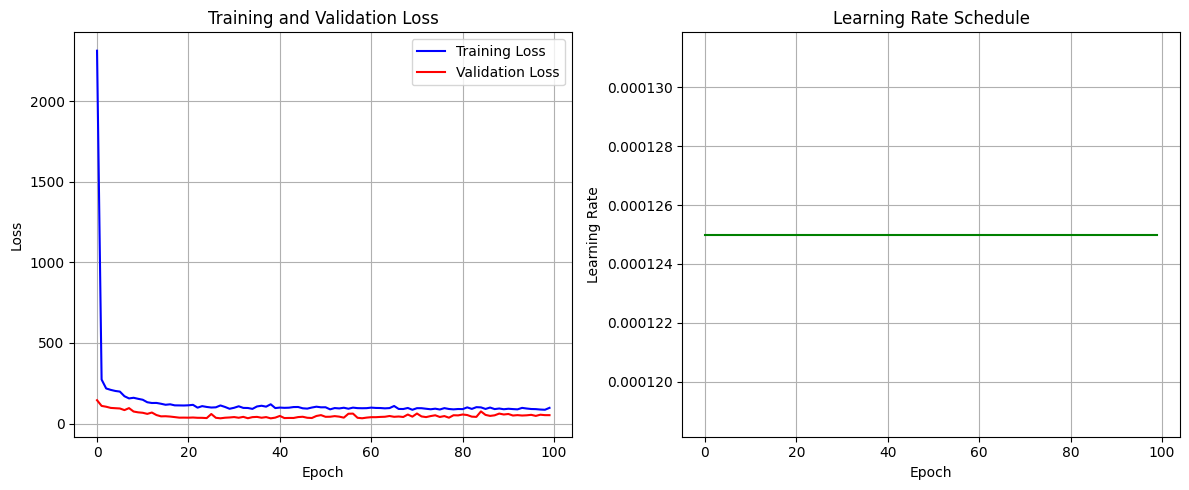

Final training loss: 97.9601
Final validation loss: 52.5958


In [14]:
# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot learning rate
plt.subplot(1, 2, 2)
lrs = [optimizer.param_groups[0]['lr'] for _ in range(num_epochs)]
plt.plot(lrs, color='green')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")

# 📈 Model Evaluation

## Making Predictions
Now let's use our trained model to make predictions on the test set and evaluate performance.

In [15]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Make predictions on test set
all_predictions = []
all_targets = []

with torch.no_grad():
    for batch_features, batch_targets in test_loader:
        batch_features = batch_features.to(device)
        predictions = model(batch_features)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_targets.numpy())

all_predictions = np.array(all_predictions).flatten()
all_targets = np.array(all_targets).flatten()

# Calculate metrics
mse = np.mean((all_predictions - all_targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(all_predictions - all_targets))
r2 = r2_score(all_targets, all_predictions)

print(f"Test Set Evaluation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Show some example predictions
print("\nSample Predictions vs Actual:")
for i in range(10):
    print(f"Predicted: {all_predictions[i]:.1f}, Actual: {all_targets[i]:.1f}, Error: {abs(all_predictions[i] - all_targets[i]):.1f}")

Test Set Evaluation Metrics:
MSE: 34.7439
RMSE: 5.8944
MAE: 4.7480
R²: 0.8172

Sample Predictions vs Actual:
Predicted: 43.6, Actual: 43.4, Error: 0.2
Predicted: 62.2, Actual: 68.5, Error: 6.3
Predicted: 72.5, Actual: 84.8, Error: 12.3
Predicted: 56.7, Actual: 49.7, Error: 6.9
Predicted: 59.0, Actual: 51.4, Error: 7.6
Predicted: 39.3, Actual: 51.8, Error: 12.4
Predicted: 72.9, Actual: 68.3, Error: 4.6
Predicted: 47.5, Actual: 48.4, Error: 0.9
Predicted: 79.8, Actual: 77.9, Error: 1.9
Predicted: 69.9, Actual: 64.3, Error: 5.6


## Visualizing Predictions
Let's create visualizations to better understand our model's performance.

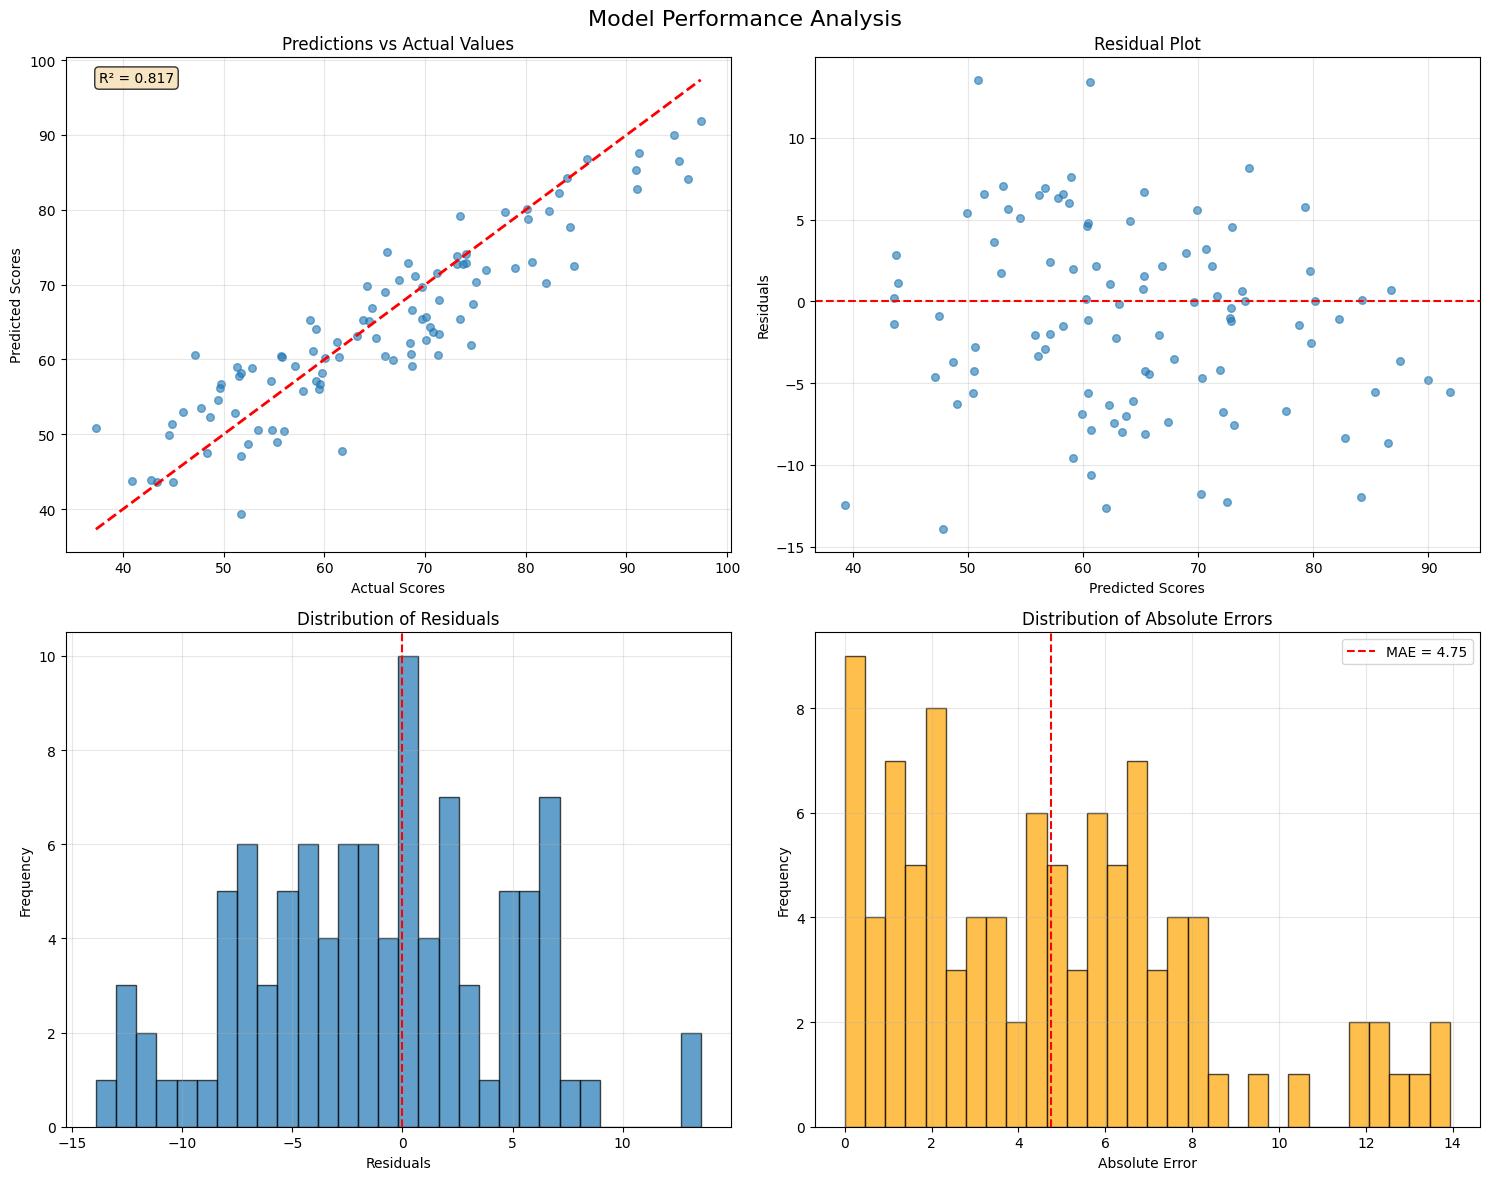

In [16]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Analysis', fontsize=16)

# 1. Predictions vs Actual scatter plot
axes[0, 0].scatter(all_targets, all_predictions, alpha=0.6, s=30)
axes[0, 0].plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Scores')
axes[0, 0].set_ylabel('Predicted Scores')
axes[0, 0].set_title('Predictions vs Actual Values')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[0, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 2. Residuals plot
residuals = all_predictions - all_targets
axes[0, 1].scatter(all_predictions, residuals, alpha=0.6, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Scores')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of residuals
axes[1, 0].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(x=0, color='r', linestyle='--')

# 4. Error distribution
errors = np.abs(residuals)
axes[1, 1].hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_xlabel('Absolute Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Absolute Errors')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(x=mae, color='r', linestyle='--', label=f'MAE = {mae:.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Testing with Custom Examples
Let's test our model with some custom student data to see how it performs on new examples.

In [17]:
# Create custom test cases
custom_students = [
    [10, 95, 85],  # High study hours, high attendance, good previous grade
    [2, 70, 60],   # Low study hours, average attendance, average previous grade
    [8, 85, 90],   # Good study hours, good attendance, excellent previous grade
    [1, 60, 45],   # Very low study hours, low attendance, poor previous grade
    [12, 98, 95]   # Excellent across all metrics
]

feature_names = ['Study Hours/Week', 'Attendance %', 'Previous Grade']
custom_tensor = torch.tensor(custom_students, dtype=torch.float32).to(device)

print("=== Custom Student Predictions ===")
model.eval()
with torch.no_grad():
    predictions = model(custom_tensor)
    predictions = predictions.cpu().numpy().flatten()

for i, (student, pred) in enumerate(zip(custom_students, predictions)):
    print(f"\nStudent {i+1}:")
    for j, (feature, value) in enumerate(zip(feature_names, student)):
        print(f"  {feature}: {value}")
    print(f"  Predicted Final Score: {pred:.1f}")

    # Add interpretation
    if pred >= 90:
        grade = "A (Excellent)"
    elif pred >= 80:
        grade = "B (Good)"
    elif pred >= 70:
        grade = "C (Average)"
    elif pred >= 60:
        grade = "D (Below Average)"
    else:
        grade = "F (Failing)"
    print(f"  Expected Grade: {grade}")

=== Custom Student Predictions ===

Student 1:
  Study Hours/Week: 10
  Attendance %: 95
  Previous Grade: 85
  Predicted Final Score: 83.3
  Expected Grade: B (Good)

Student 2:
  Study Hours/Week: 2
  Attendance %: 70
  Previous Grade: 60
  Predicted Final Score: 47.5
  Expected Grade: F (Failing)

Student 3:
  Study Hours/Week: 8
  Attendance %: 85
  Previous Grade: 90
  Predicted Final Score: 79.0
  Expected Grade: C (Average)

Student 4:
  Study Hours/Week: 1
  Attendance %: 60
  Previous Grade: 45
  Predicted Final Score: 34.7
  Expected Grade: F (Failing)

Student 5:
  Study Hours/Week: 12
  Attendance %: 98
  Previous Grade: 95
  Predicted Final Score: 93.0
  Expected Grade: A (Excellent)


# 💾 Saving and Loading Models

## Model Persistence
Learn how to save your trained model and load it later for inference or further training.

In [18]:
# Save the complete model (architecture + weights)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'model_config': {
        'input_size': 3,
        'hidden_size': 64,
        'output_size': 1
    }
}, 'complete_model_checkpoint.pth')

print("✅ Model saved successfully!")

# Demonstrate loading the model
def load_model(checkpoint_path, device):
    """Load a saved model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Recreate model
    config = checkpoint['model_config']
    loaded_model = StudentScorePredictor(
        input_size=config['input_size'],
        hidden_size=config['hidden_size'],
        output_size=config['output_size']
    )

    # Load weights
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()

    return loaded_model, checkpoint

# Test loading
loaded_model, checkpoint = load_model('complete_model_checkpoint.pth', device)
print(f"✅ Model loaded successfully!")
print(f"Best validation loss from checkpoint: {checkpoint['best_val_loss']:.4f}")

# Verify loaded model works
test_input = torch.tensor([[8, 85, 80]], dtype=torch.float32).to(device)
with torch.no_grad():
    original_pred = model(test_input)
    loaded_pred = loaded_model(test_input)

print(f"Original model prediction: {original_pred.item():.2f}")
print(f"Loaded model prediction: {loaded_pred.item():.2f}")
print(f"Difference: {abs(original_pred.item() - loaded_pred.item()):.6f}")
print("✅ Models match perfectly!" if abs(original_pred.item() - loaded_pred.item()) < 1e-6 else "❌ Models don't match")

✅ Model saved successfully!
✅ Model loaded successfully!
Best validation loss from checkpoint: 32.8827
Original model prediction: 74.31
Loaded model prediction: 74.31
Difference: 0.000000
✅ Models match perfectly!


# 🎯 Summary and Key Takeaways

## What We've Accomplished
Congratulations! You've completed a comprehensive PyTorch tutorial covering all the fundamentals.

In [21]:
print("🎉 CONGRATULATIONS! 🎉")
print("\nYou've successfully completed the PyTorch Fundamentals tutorial!")
print("\n📚 What you've learned:")
print("✅ Setting up PyTorch and checking GPU availability")
print("✅ Creating and manipulating tensors")
print("✅ Understanding GPU acceleration")
print("✅ Building neural networks with nn.Module")
print("✅ Creating custom datasets and data loaders")
print("✅ Training models with proper validation")
print("✅ Evaluating model performance")
print("✅ Visualizing results and training progress")
print("✅ Saving and loading trained models")
print("✅ Making predictions on new data")

print(f"\n📊 Final Model Performance:")
print(f"• R² Score: {r2:.3f} (higher is better, 1.0 is perfect)")
print(f"• RMSE: {rmse:.2f} points (lower is better)")
print(f"• MAE: {mae:.2f} points (lower is better)")

print("\n🚀 Next Steps:")
print("• Try different network architectures")
print("• Experiment with different optimizers and learning rates")
print("• Add more features to your dataset")
print("• Try classification problems")
print("• Explore convolutional neural networks (CNNs)")
print("• Learn about recurrent neural networks (RNNs)")
print("• Dive into transfer learning")

print("\n💡 Remember:")
print("• Start simple and gradually increase complexity")
print("• Always validate your models properly")
print("• Visualize your data and results")
print("• Don't forget to save your best models!")

🎉 CONGRATULATIONS! 🎉

You've successfully completed the PyTorch Fundamentals tutorial!

📚 What you've learned:
✅ Setting up PyTorch and checking GPU availability
✅ Creating and manipulating tensors
✅ Understanding GPU acceleration
✅ Building neural networks with nn.Module
✅ Creating custom datasets and data loaders
✅ Training models with proper validation
✅ Evaluating model performance
✅ Visualizing results and training progress
✅ Saving and loading trained models
✅ Making predictions on new data

📊 Final Model Performance:
• R² Score: 0.817 (higher is better, 1.0 is perfect)
• RMSE: 5.89 points (lower is better)
• MAE: 4.75 points (lower is better)

🚀 Next Steps:
• Try different network architectures
• Experiment with different optimizers and learning rates
• Add more features to your dataset
• Try classification problems
• Explore convolutional neural networks (CNNs)
• Learn about recurrent neural networks (RNNs)
• Dive into transfer learning

💡 Remember:
• Start simple and gradually